In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


In [3]:
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )


print("MGSD Test set balance:\n", sample_mgsd["label"].value_counts())
print("MGSD Few-shot examples balance:\n", sample_examples_mgsd["label"].value_counts())

print("MentalManip Test set balance:\n", sample_mentalmanip["manipulative"].value_counts())
print("MentalManip Few-shot examples balance:\n", sample_examples_mentalmanip["manipulative"].value_counts())

MGSD Test set balance:
 label
unrelated     250
stereotype    250
Name: count, dtype: int64
MGSD Few-shot examples balance:
 label
stereotype    5
unrelated     5
Name: count, dtype: int64
MentalManip Test set balance:
 manipulative
1    250
0    250
Name: count, dtype: int64
MentalManip Few-shot examples balance:
 manipulative
1    5
0    5
Name: count, dtype: int64


In [4]:
from dotenv import load_dotenv
import openai
import os, torch, numpy as np
from utils.call_llm import call_llm
import json
from sklearn.pipeline import make_pipeline

load_dotenv()

ENV_VARS = {
    "API_KEY_OPENAI": "OpenAI",
}

for var, name in ENV_VARS.items():
    if not os.getenv(var):
        raise ValueError(f"Missing {name} API key: `{var}` must be set in the environment.")


client = openai.OpenAI(api_key= os.getenv("API_KEY_OPENAI"))
model = "gpt-4.1-mini"
model_filename = "openai_4.1_mini"

## Chain of Thoughts

In [ ]:
from tqdm import tqdm
import os, json
import pandas as pd
from chain_of_thought import ChainOfThoughts
from stereotype_definitions import stereotype_definition_short
from manipulation_definitions import manipulation_definition_short
from cases.stereotypes_case import stereotypes_case
from cases.manipulation_case import manipulation_case
from sklearn.metrics import classification_report, confusion_matrix

# Already run: stereotype -> 2 and 4 steps, manipulation 2 steps

case_name_set = ["manipulation"]  # "stereotype" or "manipulation"
reasoning_steps = [4]
max_tokens = 700

os.makedirs(f"results/{model_filename}/cot", exist_ok=True)

try:

    for case_name in case_name_set:

        for num_steps in reasoning_steps:
            print(f"\n=== Running CoT with 700 tokens and {num_steps} reasoning steps ===")
    
            if case_name.lower() == "manipulation":
                case = manipulation_case
                task_definition = manipulation_definition_short
                data = sample_mentalmanip
            elif case_name.lower() == "stereotype":
                case = stereotypes_case
                task_definition = stereotype_definition_short
                data = sample_mgsd
            else:
                raise ValueError(f"Unknown case name: {case_name}")
    
            cot_classifier = ChainOfThoughts(
                case=case,
                client=client,
                model=model,
                max_tokens=max_tokens,
                task_definition=task_definition,
                num_reasoning_steps=num_steps,
            )
    
            rows = []
            detailed_reasoning = []
    
            for idx, row in tqdm(data.iterrows(), total=len(data), desc=f"Processing {num_steps}steps"):
                text = row[case["input_col"]]
                true_label = row[case["label_col"]]
                if isinstance(true_label, str):
                    true_label = true_label.strip()
    
                cot_result = cot_classifier.classify_with_reasoning(text)
                predicted_label = cot_result.final_label
    
                mapped_label = case["label_map"].get(predicted_label.strip(), list(case["label_map"].values())[-1])
    
                stats = cot_result.stats
    
                results = {
                    "sample_id": idx,
                    "text": text,
                    "true_label": true_label,
                    "pred_label": mapped_label,
                    "raw_pred_label": predicted_label,
                    "max_tokens": cot_classifier.max_tokens,
                    "tokens_used": stats.tokens_used if stats else None,
                    "prompt_tokens": stats.prompt_tokens if stats else None,
                    "completion_tokens": stats.completion_tokens if stats else None,
                    "latency": stats.latency if stats else None,
                    "num_reasoning_steps": len(cot_result.reasoning_steps),
                    "confidence": cot_result.confidence,
                }
    
                rows.append(results)
    
                reasoning_detail = {
                    "sample_id": idx,
                    "reasoning_steps": [
                        {"step": step.step_number, "content": step.content}
                        for step in cot_result.reasoning_steps
                    ],
                    "final_reasoning": cot_result.final_reasoning,
                    "final_label": cot_result.final_label,
                    "confidence": cot_result.confidence,
                }
    
                detailed_reasoning.append(reasoning_detail)
    
    
            output_file = f"results/{model_filename}/cot/classic/results_{case_name.lower()}_cot_{num_steps}steps.csv"
            reasoning_file = f"results/{model_filename}/cot/classic/reasoning_{case_name.lower()}_cot_{num_steps}steps.json"
    
            df_out = pd.DataFrame(rows)
            df_out.to_csv(output_file, index=False)
            print(f"=== Saved {len(df_out)} rows to {output_file} ===")
    
            with open(reasoning_file, 'w', encoding='utf-8') as f:
                json.dump(detailed_reasoning, f, indent=2, ensure_ascii=False)
            print(f"=== Saved detailed reasoning to {reasoning_file} ===")
    

            if case_name == "manipulation":
                y_true = df_out["true_label"].astype(int)
                y_pred = df_out["pred_label"].astype(int)
            elif case_name == "stereotype":
                y_true = df_out["true_label"].astype(str).str.strip().str.lower()
                y_pred = df_out["pred_label"].astype(str).str.strip().str.lower()
    
            print("\n=== Classification Report ===")
            print(classification_report(y_true, y_pred))
            print("\n=== Confusion Matrix ===")
            labels = sorted(set(y_true) | set(y_pred))
            print(pd.DataFrame(confusion_matrix(y_true, y_pred), index=labels, columns=labels))
    
            accuracy = (y_true == y_pred).mean()
            print(f"\n=== Accuracy: {accuracy:.2%} ===")
    
            metrics = cot_classifier.get_metrics()
            print(f"\n=== CoT Performance Metrics: ===")
            print(f"- Avg tokens per call: {metrics['avg_tokens_per_call']:.1f}")
            print(f"- Avg latency per call: {metrics['avg_latency_per_call']:.2f}s")
            print(f"- Total calls: {metrics['total_calls']}")
    
            print("\n Sample Reasoning Chains:")
            for i, reasoning in enumerate(detailed_reasoning[:3]):
                print(f"\nSample {reasoning['sample_id']}:")
                print(f"Final Label: {reasoning['final_label']}")
                if reasoning['confidence'] > 0:
                    print(f"Confidence: {reasoning['confidence']:.2f}")
                print("Reasoning Steps:")
                for step in reasoning['reasoning_steps']:
                    print(f"  Step {step['step']}: {step['content'][:100]}...")
                print(f"Final Reasoning: {reasoning['final_reasoning'][:150]}...")
                print("-" * 50)

except Exception as e:
    print(f"== Error with steps={num_steps}: {e} ==")
    import traceback
    traceback.print_exc()

print("\n✅ Chain-of-Thoughts Evaluation Complete")



=== Running CoT with 700 tokens and 4 reasoning steps ===


Processing 4steps: 100%|██████████| 500/500 [1:21:40<00:00,  9.80s/it]

=== Saved 500 rows to results/openai_4.1_mini/cot/classic/results_manipulation_cot_4steps.csv ===
=== Saved detailed reasoning to results/openai_4.1_mini/cot/classic/reasoning_manipulation_cot_4steps.json ===

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.60      0.68      0.64       250
           1       0.63      0.54      0.58       250

    accuracy                           0.61       500
   macro avg       0.61      0.61      0.61       500
weighted avg       0.61      0.61      0.61       500


=== Confusion Matrix ===
     0    1
0  170   80
1  115  135

=== Accuracy: 61.00% ===

=== CoT Performance Metrics: ===
- Avg tokens per call: 1238.2
- Avg latency per call: 9.80s
- Total calls: 500

 Sample Reasoning Chains:

Sample 0:
Final Label: Yes
Reasoning Steps:
  Step 1: - The dialogue shows Person1 trying to engage Person2 emotionally, expressing vulnerability ("You kn...
  Step 2: - Relevant features for manipulation

In [5]:
from tqdm import tqdm
import os, json
import pandas as pd
from chain_of_thought import ChainOfThoughts
from stereotype_definitions import stereotype_definition_short_binary
from manipulation_definitions import manipulation_definition_short
from sklearn.metrics import classification_report, confusion_matrix
from cases.get_case_config import get_case_config
from cases.stereotypes_case import stereotypes_case
from cases.manipulation_case import manipulation_case

# Test different CoT strategies
case_name_set = ["stereotype"]  # "stereotype" or "manipulation"
strategies = ["zero_plus", "optimized"]  # Test both new strategies.   "optimized", "zero_plus"
max_tokens = 700

os.makedirs(f"results/{model_filename}/cot/new_strategies", exist_ok=True)

try:
    for case_name in case_name_set:
        
        for strategy in strategies:
            print(f"\n=== Running CoT with strategy: {strategy} ===")
    
            if case_name.lower() == "manipulation":
                case = manipulation_case
                task_definition = manipulation_definition_short
                data = sample_mentalmanip
            elif case_name.lower() == "stereotype":
                case = stereotypes_case
                task_definition = stereotype_definition_short_binary
                data = sample_mgsd
            else:
                raise ValueError(f"Unknown case name: {case_name}")
    
            cot_classifier = ChainOfThoughts(
                case=case,
                client=client,
                model=model,
                max_tokens=max_tokens,
                task_definition=task_definition,
                num_reasoning_steps=3,
            )
    
            rows = []
            detailed_reasoning = []
    
            for idx, row in tqdm(data.iterrows(), total=len(data), desc=f"Processing {strategy}"):
                text = row[case.input_col]
                true_label = row[case.label_col] 
                if isinstance(true_label, str):
                    true_label = true_label.strip()
    
                try:
                    cot_result = cot_classifier.classify_with_strategy(text, strategy=strategy)
                    predicted_label = cot_result.final_label
        
                    mapped_label = case.label_map.get(predicted_label.strip(), list(case.label_map.values())[-1])
        
                    stats = cot_result.stats
        
                    results = {
                        "sample_id": idx,
                        "text": text,
                        "true_label": true_label,
                        "pred_label": mapped_label,
                        "raw_pred_label": predicted_label,
                        "strategy": strategy,
                        "max_tokens": cot_classifier.max_tokens,
                        "tokens_used": stats.tokens_used if stats else None,
                        "prompt_tokens": stats.prompt_tokens if stats else None,
                        "completion_tokens": stats.completion_tokens if stats else None,
                        "latency": stats.latency if stats else None,
                        "num_reasoning_steps": len(cot_result.reasoning_steps) if cot_result.reasoning_steps else 0,
                        "confidence": cot_result.confidence,
                    }
        
                    rows.append(results)
        
                    reasoning_detail = {
                        "sample_id": idx,
                        "strategy": strategy,
                        "reasoning_steps": [
                            {"step": step.step_number, "content": step.content}
                            for step in cot_result.reasoning_steps
                        ] if cot_result.reasoning_steps else [],
                        "final_reasoning": cot_result.final_reasoning,
                        "final_label": cot_result.final_label,
                        "confidence": cot_result.confidence,
                    }
        
                    detailed_reasoning.append(reasoning_detail)
                
                except Exception as e:
                    print(f"Error processing sample {idx}: {e}")
                    continue
    
            if not rows:
                print(f"No successful classifications for {strategy}")
                continue
                
            output_file = f"results/{model_filename}/cot/new_strategies/results_{case_name.lower()}_cot_{strategy}.csv"
            reasoning_file = f"results/{model_filename}/cot/new_strategies/reasoning_{case_name.lower()}_cot_{strategy}.json"
    
            df_out = pd.DataFrame(rows)
            df_out.to_csv(output_file, index=False)
            print(f"=== Saved {len(df_out)} rows to {output_file} ===")
    
            with open(reasoning_file, 'w', encoding='utf-8') as f:
                json.dump(detailed_reasoning, f, indent=2, ensure_ascii=False)
            print(f"=== Saved detailed reasoning to {reasoning_file} ===")
    
            try:
                if case_name == "manipulation":
                    y_true = df_out["true_label"].astype(int)
                    y_pred = df_out["pred_label"].astype(int)
                elif case_name == "stereotype":
                    y_true = df_out["true_label"].astype(str).str.strip().str.lower()
                    y_pred = df_out["pred_label"].astype(str).str.strip().str.lower()
        
                print(f"\n=== Classification Report for {strategy} ===")
                print(classification_report(y_true, y_pred, zero_division=0))
                print(f"\n=== Confusion Matrix for {strategy} ===")
                labels = sorted(set(y_true) | set(y_pred))
                print(pd.DataFrame(confusion_matrix(y_true, y_pred, labels=labels), index=labels, columns=labels))
        
                accuracy = (y_true == y_pred).mean()
                print(f"\n=== Accuracy for {strategy}: {accuracy:.2%} ===")
            except Exception as e:
                print(f"Error in evaluation for {strategy}: {e}")
    
            metrics = cot_classifier.get_metrics()
            print(f"\n=== CoT Performance Metrics for {strategy}: ===")
            print(f"- Avg tokens per call: {metrics['avg_tokens_per_call']:.1f}")
            print(f"- Avg latency per call: {metrics['avg_latency_per_call']:.2f}s")
            print(f"- Total calls: {metrics['total_calls']}")
    
            print(f"\n Sample Reasoning Chains for {strategy}:")
            for i, reasoning in enumerate(detailed_reasoning[:3]):
                print(f"\nSample {reasoning['sample_id']}:")
                print(f"Final Label: {reasoning['final_label']}")
                if reasoning.get('confidence') not in (None, 0, "None"):
                    print(f"Confidence: {reasoning['confidence']}")
                print("Reasoning Steps:")
                for step in reasoning['reasoning_steps']:
                    print(f"  Step {step['step']}: {step['content'][:100]}...")
                print(f"Final Reasoning: {reasoning['final_reasoning'][:150]}...")
                print("-" * 50)

except Exception as e:
    print(f"== Error with strategy: {e} ==")
    import traceback
    traceback.print_exc()

print("\n✅ New CoT Strategy Evaluation Complete")

print("\n=== STRATEGY COMPARISON ===")
try:
    if len(case_name_set) > 0:
        optimized_file = f"results/{model_filename}/cot/new_strategies/results_{case_name_set[0].lower()}_cot_optimized.csv"
        zero_plus_file = f"results/{model_filename}/cot/new_strategies/results_{case_name_set[0].lower()}_cot_zero_plus.csv"
        
        if os.path.exists(optimized_file) and os.path.exists(zero_plus_file):
            df_optimized = pd.read_csv(optimized_file)
            df_zero_plus = pd.read_csv(zero_plus_file)
            
            print("\nPerformance Comparison:")
            for df, strategy in [(df_optimized, "optimized"), (df_zero_plus, "zero_plus")]:
                if case_name_set[0] == "manipulation":
                    accuracy = (df["true_label"].astype(int) == df["pred_label"].astype(int)).mean()
                else:
                    accuracy = (df["true_label"].astype(str).str.strip().str.lower() == 
                               df["pred_label"].astype(str).str.strip().str.lower()).mean()
                
                avg_latency = df["latency"].mean()
                avg_tokens = df["tokens_used"].mean()
                
                print(f"{strategy:12s}: {accuracy:.1%} accuracy, {avg_latency:.1f}s avg latency, {avg_tokens:.0f} avg tokens")
        else:
            print("Strategy comparison files not found.")
            
except Exception as e:
    print(f"Could not compare strategies: {e}")


=== Running CoT with strategy: zero_plus ===


Processing zero_plus:   0%|          | 1/500 [00:01<14:29,  1.74s/it]

[WARN] Failed to parse structured output: 1 validation error for CoTResult
__root__
  Expecting value: line 1 column 1 (char 0) [type=value_error.jsondecode, input_value='Classification: No\nCertain: Yes', input_type=str]


Processing zero_plus:   0%|          | 2/500 [00:02<09:40,  1.16s/it]

[WARN] Failed to parse structured output: 1 validation error for CoTResult
__root__
  Expecting value: line 1 column 1 (char 0) [type=value_error.jsondecode, input_value='Classification: Yes  \nCertain: Yes', input_type=str]


Processing zero_plus:   1%|          | 3/500 [00:03<09:05,  1.10s/it]

[WARN] Failed to parse structured output: 1 validation error for CoTResult
__root__
  Expecting value: line 1 column 1 (char 0) [type=value_error.jsondecode, input_value='Classification: No\nCertain: Yes', input_type=str]


Processing zero_plus:   1%|          | 4/500 [00:04<09:28,  1.15s/it]

[WARN] Failed to parse structured output: 1 validation error for CoTResult
__root__
  Expecting value: line 1 column 1 (char 0) [type=value_error.jsondecode, input_value='Classification: Yes\nCertain: Yes', input_type=str]


KeyboardInterrupt: 

## Role playing with Chain-of-Thoughts

In [ ]:
from tqdm import tqdm
import os, json
import pandas as pd
from chain_of_thought import ChainOfThoughts
from stereotype_definitions import stereotype_definition_short
from manipulation_definitions import manipulation_definition_short
from cases.get_case_config import get_case_config
from cases.stereotypes_case import stereotypes_case
from cases.manipulation_case import manipulation_case
from sklearn.metrics import classification_report, confusion_matrix

case_name_set = ["stereotype"]  # , "manipulation" # "stereotype" or "manipulation"
reasoning_steps = [2] #[2, 4]
max_tokens = 700
role_playing_modes = ["active"] #["active", "passive"]
selected_profiles = ["profile1", "profile2", "profile10"]

os.makedirs(f"results/{model_filename}/cot", exist_ok=True)

try:

    for person_key in selected_profiles:
        for role_playing in role_playing_modes:
            for case_name in case_name_set:
                for num_steps in reasoning_steps:
                    print(f"\n=== Running CoT with 700 tokens and {num_steps} reasoning steps ===")
            
                    if case_name.lower() == "manipulation":
                        case = manipulation
                        task_definition = manipulation_definition_short
                        data = sample_mentalmanip
                    elif case_name.lower() == "stereotype":
                        case = stereotypes
                        task_definition = stereotype_definition_short
                        data = sample_mgsd
                    else:
                        raise ValueError(f"Unknown case name: {case_name}")
            
                    cot_classifier = ChainOfThoughts(
                        case=case,
                        client=client,
                        model=model,
                        max_tokens=max_tokens,
                        task_definition=task_definition,
                        num_reasoning_steps=num_steps,
                        person_key=person_key,
                        role_playing=role_playing,
                    )
            
                    rows = []
                    detailed_reasoning = []
            
                    for idx, row in tqdm(data.iterrows(), total=len(data), desc=f"Processing {num_steps}steps"):
                        text = row[case["input_col"]]
                        true_label = row[case["label_col"]]
                        if isinstance(true_label, str):
                            true_label = true_label.strip()
            
                        cot_result = cot_classifier.classify_with_reasoning(text)
                        predicted_label = cot_result.final_label
            
                        mapped_label = case["label_map"].get(predicted_label.strip(), list(case["label_map"].values())[-1])
            
                        stats = cot_result.stats
            
                        results = {
                            "sample_id": idx,
                            "text": text,
                            "true_label": true_label,
                            "pred_label": mapped_label,
                            "raw_pred_label": predicted_label,
                            "max_tokens": cot_classifier.max_tokens,
                            "tokens_used": stats.tokens_used if stats else None,
                            "prompt_tokens": stats.prompt_tokens if stats else None,
                            "completion_tokens": stats.completion_tokens if stats else None,
                            "latency": stats.latency if stats else None,
                            "num_reasoning_steps": len(cot_result.reasoning_steps),
                            "confidence": cot_result.confidence,
                            "person_key": cot_result.person_key,
                            "role_playing": cot_result.role_playing,
                        }
            
                        rows.append(results)
            
                        reasoning_detail = {
                            "sample_id": idx,
                            "reasoning_steps": [
                                {"step": step.step_number, "content": step.content}
                                for step in cot_result.reasoning_steps
                            ],
                            "final_reasoning": cot_result.final_reasoning,
                            "final_label": cot_result.final_label,
                            "confidence": cot_result.confidence,
                            "person_key": cot_result.person_key,
                            "role_playing": cot_result.role_playing,
                        }
            
                        detailed_reasoning.append(reasoning_detail)
            
            
                    output_file = f"results/{model_filename}/cot/role_playing/{person_key}_{role_playing}/results_{case_name.lower()}_cot_{num_steps}steps.csv"
                    reasoning_file = f"results/{model_filename}/cot/role_playing/{person_key}_{role_playing}/reasoning_{case_name.lower()}_cot_{num_steps}steps.json"
            
                    df_out = pd.DataFrame(rows)
                    df_out.to_csv(output_file, index=False)
                    print(f"=== Saved {len(df_out)} rows to {output_file} ===")
            
                    with open(reasoning_file, 'w', encoding='utf-8') as f:
                        json.dump(detailed_reasoning, f, indent=2, ensure_ascii=False)
                    print(f"=== Saved detailed reasoning to {reasoning_file} ===")
            
        
                    if case_name == "manipulation":
                        y_true = df_out["true_label"].astype(int)
                        y_pred = df_out["pred_label"].astype(int)
                    elif case_name == "stereotype":
                        y_true = df_out["true_label"].astype(str).str.strip().str.lower()
                        y_pred = df_out["pred_label"].astype(str).str.strip().str.lower()
            
                    print("\n=== Classification Report ===")
                    print(classification_report(y_true, y_pred))
                    print("\n=== Confusion Matrix ===")
                    labels = sorted(set(y_true) | set(y_pred))
                    print(pd.DataFrame(confusion_matrix(y_true, y_pred), index=labels, columns=labels))
            
                    accuracy = (y_true == y_pred).mean()
                    print(f"\n=== Accuracy: {accuracy:.2%} ===")
            
                    metrics = cot_classifier.get_metrics()
                    print(f"\n=== CoT Performance Metrics: ===")
                    print(f"- Avg tokens per call: {metrics['avg_tokens_per_call']:.1f}")
                    print(f"- Avg latency per call: {metrics['avg_latency_per_call']:.2f}s")
                    print(f"- Total calls: {metrics['total_calls']}")
            
                    print("\n Sample Reasoning Chains:")
                    for i, reasoning in enumerate(detailed_reasoning[:3]):
                        print(f"\nSample {reasoning['sample_id']}:")
                        print(f"Final Label: {reasoning['final_label']}")
                        if reasoning['confidence'] > 0:
                            print(f"Confidence: {reasoning['confidence']:.2f}")
                        print("Reasoning Steps:")
                        for step in reasoning['reasoning_steps']:
                            print(f"  Step {step['step']}: {step['content'][:100]}...")
                        print(f"Final Reasoning: {reasoning['final_reasoning'][:150]}...")
                        print("-" * 50)

except Exception as e:
    print(f"== Error with steps={num_steps}: {e} ==")
    import traceback
    traceback.print_exc()

print("\n✅ Chain-of-Thoughts Evaluation Complete")


=== Reasoning Steps: 2 ===
              precision    recall  f1-score   support

           0      0.594     0.475     0.528        40
           1      0.691     0.783     0.734        60

    accuracy                          0.660       100
   macro avg      0.642     0.629     0.631       100
weighted avg      0.652     0.660     0.652       100


=== Reasoning Steps: 3 ===
              precision    recall  f1-score   support

           0      0.769     0.500     0.606        40
           1      0.730     0.900     0.806        60

    accuracy                          0.740       100
   macro avg      0.749     0.700     0.706       100
weighted avg      0.746     0.740     0.726       100


=== Reasoning Steps: 4 ===
              precision    recall  f1-score   support

           0      0.667     0.500     0.571        40
           1      0.714     0.833     0.769        60

    accuracy                          0.700       100
   macro avg      0.690     0.667     0.670 

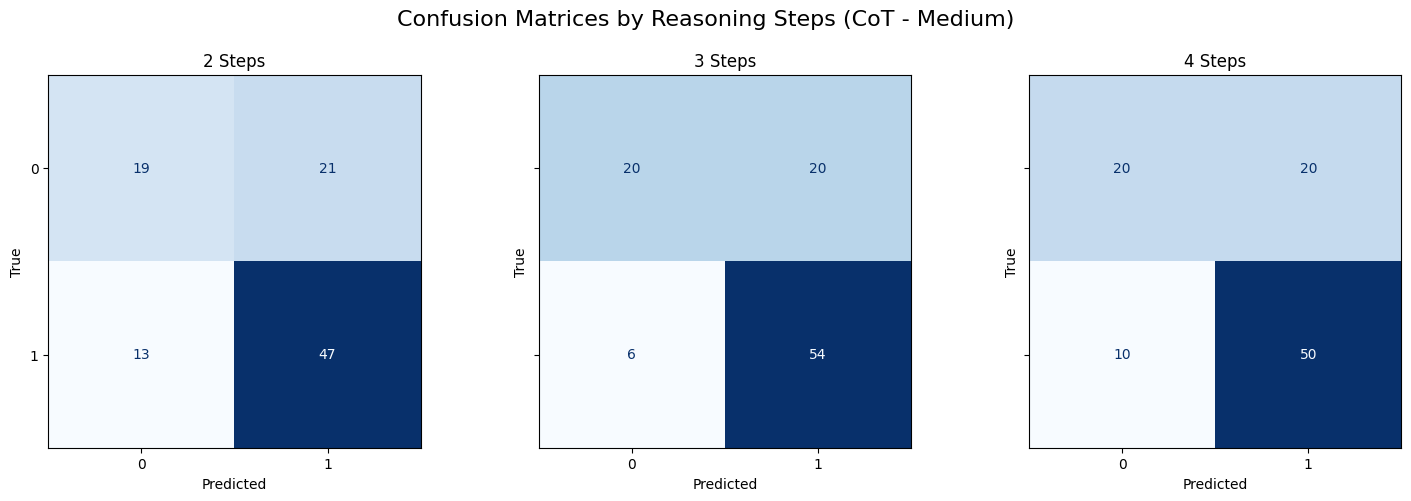


=== Accuracy Table ===

           accuracy  count
num_steps                 
2              0.66    100
3              0.74    100
4              0.70    100


In [16]:
import pandas as pd
import os
import re
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results_dir = "results/cot/medium"
records = []

for file in os.listdir(results_dir):
    if re.match(r"results_manipulation_cot_\dsteps\.csv", file):
        match = re.search(r"cot_(\d)steps", file)
        if match:
            num_steps = int(match.group(1))
            df = pd.read_csv(os.path.join(results_dir, file))
            df["num_steps"] = num_steps
            df["regime"] = "medium"
            records.append(df)

cot_results = pd.concat(records, ignore_index=True)


grouped = cot_results.groupby("num_steps")

for num_steps, group in grouped:
    print(f"\n=== Reasoning Steps: {num_steps} ===")
    y_true = group["true_label"].astype(int)
    y_pred = group["pred_label"].astype(int)
    print(classification_report(y_true, y_pred, digits=3))


def plot_confusion_matrix_sklearn(y_true, y_pred, title="Confusion Matrix", ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format='d')
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for i, num_steps in enumerate(sorted(cot_results["num_steps"].unique())):
    ax = axes[i]
    subset = cot_results[cot_results["num_steps"] == num_steps]
    y_true = subset["true_label"].astype(int)
    y_pred = subset["pred_label"].astype(int)
    plot_confusion_matrix_sklearn(y_true, y_pred, title=f"{num_steps} Steps", ax=ax)

fig.suptitle("Confusion Matrices by Reasoning Steps (CoT - Medium)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


summary = (
    cot_results
    .assign(correct=lambda df: df["true_label"] == df["pred_label"])
    .groupby("num_steps")
    .agg(accuracy=("correct", "mean"), count=("correct", "size"))
    .reset_index()
)

print("\n=== Accuracy Table ===\n")
print(summary.set_index("num_steps").round(3))
